# Laboratorio: Algoritmos Genéticos - Curso 1
**Universidad de Cundinamarca - Seccional Ubaté**
**Programa de Ingeniería de Sistemas y Computación**
**Docente:** Fabio Alejandro Sastoque Rincón

**Integrantes:**
- Juan david vasquez
- Felipe Forero

---
Este notebook desarrolla los 4 ejercicios de la actividad *"Exploración y Optimización Matemática"*:

1. Maximización cúbica (una variable)
2. Optimización multivariable (dos variables)
3. Impacto de la tasa de mutación
4. Elitismo ampliado (top-3)

La estructura es: **funciones base del algoritmo genético** → luego cada ejercicio las reutiliza,
adaptando únicamente la función de aptitud y los parámetros que pide el enunciado.


In [8]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Semilla fija para que las corridas sean reproducibles mientras prueban el código.
# Pueden comentar esta línea si quieren ver variabilidad entre ejecuciones.
random.seed(42)


## 1. Funciones base del Algoritmo Genético

Estas funciones son el "motor" reutilizado en los 4 ejercicios:

- `crear_individuo` / `crear_poblacion`: generan cromosomas binarios aleatorios.
- `decodificar`: convierte un cromosoma binario en 1 o más variables reales (soporta
  multivariable dividiendo el cromosoma en bloques de bits, tal como pide el Ejercicio 2).
- `seleccion_torneo`: selección por torneo (funciona igual con fitness positivo o negativo,
  lo cual es importante para el Ejercicio 2 donde se usa el valor negativo de la función).
- `cruce`: cruce de un punto.
- `mutacion`: mutación bit a bit.
- `algoritmo_genetico`: ciclo principal, con **elitismo configurable** mediante el parámetro
  `n_elite` (usado directamente en el Ejercicio 4).


In [9]:
# =========================================================
# FUNCIONES BASE DEL ALGORITMO GENÉTICO
# =========================================================

def crear_individuo(n_bits):
    """Crea un cromosoma binario aleatorio de longitud n_bits."""
    return [random.randint(0, 1) for _ in range(n_bits)]


def crear_poblacion(tam_poblacion, n_bits):
    """Crea una población inicial de individuos binarios aleatorios."""
    return [crear_individuo(n_bits) for _ in range(tam_poblacion)]


def bits_a_entero(bits):
    """Convierte una sublista de bits (0/1) en su valor entero equivalente."""
    entero = 0
    for bit in bits:
        entero = (entero << 1) | bit
    return entero


def decodificar(individuo, n_vars, bits_por_var, xmin, xmax):
    """
    Decodifica un cromosoma binario en 'n_vars' variables reales.

    - individuo: lista de bits (0/1) de longitud n_vars * bits_por_var
    - bits_por_var: cuántos bits se usan para representar cada variable
    - xmin, xmax: límites del espacio de búsqueda. Pueden ser un solo número
      (misma cota para todas las variables) o una lista con una cota por variable.

    Retorna una lista con los valores reales decodificados, uno por variable.
    """
    if not isinstance(xmin, (list, tuple)):
        xmin = [xmin] * n_vars
    if not isinstance(xmax, (list, tuple)):
        xmax = [xmax] * n_vars

    valores = []
    max_entero = (2 ** bits_por_var) - 1

    for i in range(n_vars):
        inicio = i * bits_por_var
        fin = inicio + bits_por_var
        sub_bits = individuo[inicio:fin]
        entero = bits_a_entero(sub_bits)
        valor_real = xmin[i] + (entero / max_entero) * (xmax[i] - xmin[i])
        valores.append(valor_real)

    return valores


def seleccion_torneo(poblacion, fitness_poblacion, k=3):
    """
    Selección por torneo: escoge k individuos al azar y retorna
    una copia del que tenga mejor fitness (mayor valor).
    Funciona igual con fitness positivos o negativos.
    """
    participantes = random.sample(range(len(poblacion)), k)
    mejor = max(participantes, key=lambda idx: fitness_poblacion[idx])
    return poblacion[mejor][:]


def cruce(padre1, padre2, pc=0.8):
    """Cruce de un punto. Con probabilidad pc se intercambian los cromosomas."""
    if random.random() < pc:
        punto = random.randint(1, len(padre1) - 1)
        hijo1 = padre1[:punto] + padre2[punto:]
        hijo2 = padre2[:punto] + padre1[punto:]
        return hijo1, hijo2
    return padre1[:], padre2[:]


def mutacion(individuo, pm):
    """Mutación bit a bit: cada gen puede invertirse con probabilidad pm."""
    return [1 - bit if random.random() < pm else bit for bit in individuo]


### Ciclo principal con elitismo configurable

La función `algoritmo_genetico` recibe `n_elite` como parámetro: la cantidad de mejores
individuos que se preservan **intactos** (sin cruce ni mutación) hacia la siguiente
generación. Por defecto `n_elite=1` (elitismo clásico); en el **Ejercicio 4** simplemente
se invoca con `n_elite=3`, que es exactamente la modificación que pide el enunciado.


In [10]:
def algoritmo_genetico(funcion_aptitud, n_vars, bits_por_var, xmin, xmax,
                        tam_poblacion=40, n_generaciones=60,
                        pc=0.8, pm=0.05, n_elite=1, k_torneo=3):
    """
    Algoritmo genético general.

    - funcion_aptitud: función que recibe una lista de valores reales
      [x1, x2, ...] y retorna un número (fitness a MAXIMIZAR).
    - n_vars: número de variables del problema (1 para el Ejercicio 1, 2 para el Ejercicio 2).
    - bits_por_var: bits usados para codificar cada variable.
    - xmin, xmax: límites del espacio de búsqueda (número o lista por variable).
    - n_elite: cuántos de los mejores individuos se preservan intactos de una
      generación a otra (Ejercicio 4 usa n_elite=3 en lugar del valor por defecto 1).

    Retorna: (mejor_individuo, mejor_valores_reales, mejor_fitness, historial_convergencia)
    """
    n_bits_total = n_vars * bits_por_var
    poblacion = crear_poblacion(tam_poblacion, n_bits_total)
    historial = []

    for generacion in range(n_generaciones):
        # Evaluar aptitud de toda la población
        valores_decodificados = [decodificar(ind, n_vars, bits_por_var, xmin, xmax) for ind in poblacion]
        fitness_poblacion = [funcion_aptitud(v) for v in valores_decodificados]

        # Guardar el mejor fitness de esta generación para la gráfica de convergencia
        historial.append(max(fitness_poblacion))

        # --- ELITISMO ---
        # Ordenamos los índices de mejor a peor fitness y preservamos
        # los 'n_elite' individuos intactos para la siguiente generación.
        indices_ordenados = sorted(range(tam_poblacion),
                                    key=lambda idx: fitness_poblacion[idx],
                                    reverse=True)
        elite = [poblacion[idx][:] for idx in indices_ordenados[:n_elite]]

        # --- NUEVA GENERACIÓN ---
        nueva_poblacion = elite[:]  # los élite pasan directo, sin cruce ni mutación

        while len(nueva_poblacion) < tam_poblacion:
            padre1 = seleccion_torneo(poblacion, fitness_poblacion, k=k_torneo)
            padre2 = seleccion_torneo(poblacion, fitness_poblacion, k=k_torneo)
            hijo1, hijo2 = cruce(padre1, padre2, pc)
            hijo1 = mutacion(hijo1, pm)
            hijo2 = mutacion(hijo2, pm)
            nueva_poblacion.append(hijo1)
            if len(nueva_poblacion) < tam_poblacion:
                nueva_poblacion.append(hijo2)

        poblacion = nueva_poblacion

    # Evaluación final para reportar el mejor individuo
    valores_decodificados = [decodificar(ind, n_vars, bits_por_var, xmin, xmax) for ind in poblacion]
    fitness_poblacion = [funcion_aptitud(v) for v in valores_decodificados]
    mejor_idx = max(range(tam_poblacion), key=lambda idx: fitness_poblacion[idx])

    return poblacion[mejor_idx], valores_decodificados[mejor_idx], fitness_poblacion[mejor_idx], historial


## Ejercicio 1 - Maximización Cúbica

Se busca maximizar $f(x) = x^3 - 4x^2 + 5x$.

**Elección del espacio de búsqueda:** derivando, $f'(x) = 3x^2 - 8x + 5 = 0$ tiene raíces
en $x=1$ y $x=5/3$. En $x=1$, $f''(1) < 0$, por lo que allí hay un **máximo local** con
$f(1)=2$. Factorizando, $f(x)-2 = (x-1)^2(x-2)$, lo que muestra que $f(x)$ vuelve a valer
2 justo en $x=2$ antes de dispararse hacia arriba sin límite. Por eso se define el rango de
búsqueda en **[0, 1.9]**: así el máximo local en $x=1$ queda estrictamente por encima de
ambos extremos del intervalo ($f(0)=0$, $f(1.9)\approx1.92$), sin empates que puedan
confundir la convergencia, y el algoritmo genético debe converger al punto interior $x=1$.


Mejor x encontrado: 1.00000
f(x) = 2.00000  (valor teórico esperado: x=1, f(x)=2)


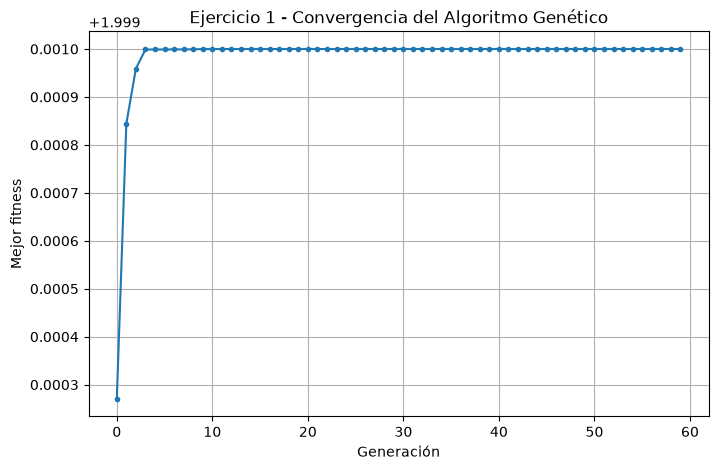

In [11]:
def fitness_ej1(valores):
    """Función de aptitud del Ejercicio 1: MAXIMIZAR f(x) = x^3 - 4x^2 + 5x."""
    x = valores[0]
    return x**3 - 4*x**2 + 5*x


XMIN_EJ1, XMAX_EJ1 = 0, 1.9
BITS_EJ1 = 16  # resolución alta para distinguir valores de x muy cercanos

mejor_ind1, mejor_valores1, mejor_fit1, historial_ej1 = algoritmo_genetico(
    funcion_aptitud=fitness_ej1,
    n_vars=1,
    bits_por_var=BITS_EJ1,
    xmin=XMIN_EJ1,
    xmax=XMAX_EJ1,
    tam_poblacion=40,
    n_generaciones=60,
    pc=0.8,
    pm=0.05,
    n_elite=1
)

print(f"Mejor x encontrado: {mejor_valores1[0]:.5f}")
print(f"f(x) = {mejor_fit1:.5f}  (valor teórico esperado: x=1, f(x)=2)")

plt.figure(figsize=(8, 5))
plt.plot(historial_ej1, marker='o', markersize=3)
plt.title("Ejercicio 1 - Convergencia del Algoritmo Genético")
plt.xlabel("Generación")
plt.ylabel("Mejor fitness")
plt.grid(True)
plt.show()


## Ejercicio 2 - Optimización Multivariable

Se busca **minimizar** $f(x,y) = x^2 + y^2$. Como `algoritmo_genetico` siempre maximiza,
la función de aptitud retorna $-f(x,y)$: maximizar $-f(x,y)$ equivale a minimizar $f(x,y)$.

El cromosoma se divide en dos bloques de 4 bits (8 bits en total), como pide el enunciado:
los primeros 4 bits codifican $x$ y los últimos 4 bits codifican $y$, ambos mapeados al
rango $[-5, 5]$. El óptimo teórico es $(x,y)=(0,0)$ con $f=0$.


Mejor (x, y) encontrado: (-0.3333, 0.3333)
f(x, y) = 0.22222  (valor real minimizado; óptimo teórico = 0 en (0,0))


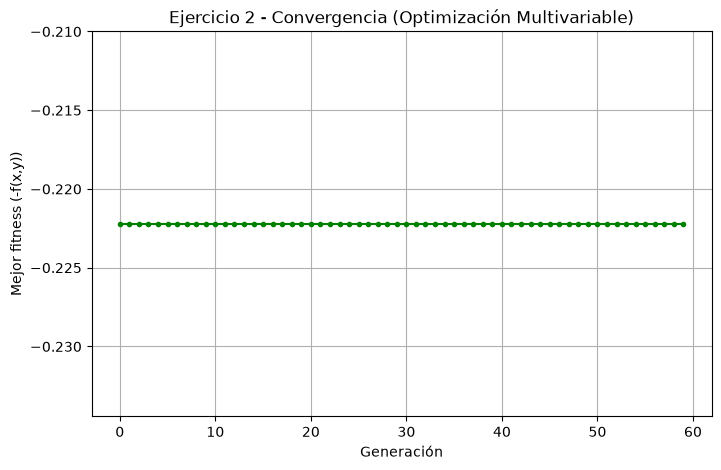

In [12]:
def fitness_ej2(valores):
    """
    Función de aptitud del Ejercicio 2.
    Se quiere MINIMIZAR f(x, y) = x^2 + y^2, así que se retorna el valor negativo.
    """
    x, y = valores
    return -(x**2 + y**2)


XMIN_EJ2, XMAX_EJ2 = -5, 5
BITS_POR_VAR_EJ2 = 4  # 4 bits para x + 4 bits para y = 8 bits en total

mejor_ind2, mejor_valores2, mejor_fit2, historial_ej2 = algoritmo_genetico(
    funcion_aptitud=fitness_ej2,
    n_vars=2,
    bits_por_var=BITS_POR_VAR_EJ2,
    xmin=XMIN_EJ2,
    xmax=XMAX_EJ2,
    tam_poblacion=40,
    n_generaciones=60,
    pc=0.8,
    pm=0.05,
    n_elite=1
)

x_opt, y_opt = mejor_valores2
print(f"Mejor (x, y) encontrado: ({x_opt:.4f}, {y_opt:.4f})")
print(f"f(x, y) = {-mejor_fit2:.5f}  (valor real minimizado; óptimo teórico = 0 en (0,0))")

plt.figure(figsize=(8, 5))
plt.plot(historial_ej2, marker='o', markersize=3, color='green')
plt.title("Ejercicio 2 - Convergencia (Optimización Multivariable)")
plt.xlabel("Generación")
plt.ylabel("Mejor fitness (-f(x,y))")
plt.grid(True)
plt.show()


## Ejercicio 3 - Impacto de la Tasa de Mutación

Se ejecuta el algoritmo del Ejercicio 1 tres veces, variando **solo** la probabilidad de
mutación: `pm = 0.01`, `pm = 0.1` y `pm = 0.5`. Se grafican las tres curvas de
convergencia juntas para compararlas.


pm = 0.01 -> mejor x = 1.00939, f(x) = 1.99991
pm = 0.1 -> mejor x = 1.00000, f(x) = 2.00000
pm = 0.5 -> mejor x = 1.00078, f(x) = 2.00000


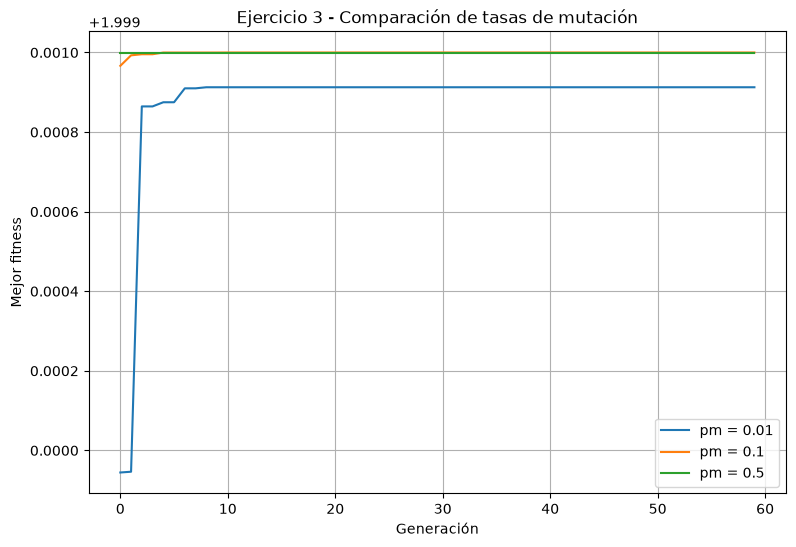

In [13]:
tasas_mutacion = [0.01, 0.1, 0.5]
resultados_ej3 = {}

for pm in tasas_mutacion:
    _, valores_pm, fit_pm, historial_pm = algoritmo_genetico(
        funcion_aptitud=fitness_ej1,
        n_vars=1,
        bits_por_var=BITS_EJ1,
        xmin=XMIN_EJ1,
        xmax=XMAX_EJ1,
        tam_poblacion=40,
        n_generaciones=60,
        pc=0.8,
        pm=pm,
        n_elite=1
    )
    resultados_ej3[pm] = historial_pm
    print(f"pm = {pm} -> mejor x = {valores_pm[0]:.5f}, f(x) = {fit_pm:.5f}")

plt.figure(figsize=(9, 6))
for pm, historial in resultados_ej3.items():
    plt.plot(historial, label=f"pm = {pm}")

plt.title("Ejercicio 3 - Comparación de tasas de mutación")
plt.xlabel("Generación")
plt.ylabel("Mejor fitness")
plt.legend()
plt.grid(True)
plt.show()


**Interpretación esperada** (verifíquenla contra sus propias gráficas):

- `pm = 0.01`: mutación baja, convergencia más estable pero con riesgo de estancarse en un
  óptimo local si la población pierde diversidad demasiado pronto.
- `pm = 0.1`: balance razonable entre exploración y explotación; suele converger de forma
  confiable al óptimo.
- `pm = 0.5`: mutación muy alta, casi la mitad de los genes se invierten en cada individuo;
  esto introduce demasiado ruido y puede impedir que el algoritmo explote las buenas
  soluciones encontradas, generando una curva más errática.

*(Agreguen aquí su propia conclusión con base en los resultados obtenidos.)*


## Ejercicio 4 - Elitismo Ampliado

La función `algoritmo_genetico` ya tiene el parámetro `n_elite`. La línea clave es:

```python
elite = [poblacion[idx][:] for idx in indices_ordenados[:n_elite]]
```

Por defecto se usó `n_elite=1` (elitismo clásico: solo el mejor individuo pasa intacto).
La modificación pedida en este ejercicio consiste en **cambiar ese valor a 3**, de modo
que los 3 mejores individuos de cada generación se preserven intactos hacia la siguiente,
en lugar de solo el mejor. A continuación se comparan ambas configuraciones.


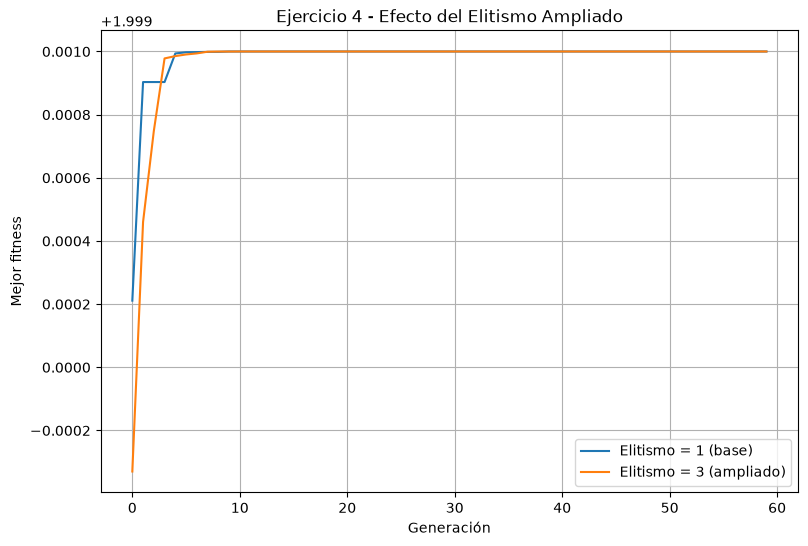

In [14]:
_, _, _, historial_elite1 = algoritmo_genetico(
    funcion_aptitud=fitness_ej1, n_vars=1, bits_por_var=BITS_EJ1,
    xmin=XMIN_EJ1, xmax=XMAX_EJ1, pm=0.05, n_elite=1
)

_, _, _, historial_elite3 = algoritmo_genetico(
    funcion_aptitud=fitness_ej1, n_vars=1, bits_por_var=BITS_EJ1,
    xmin=XMIN_EJ1, xmax=XMAX_EJ1, pm=0.05, n_elite=3
)

plt.figure(figsize=(9, 6))
plt.plot(historial_elite1, label="Elitismo = 1 (base)")
plt.plot(historial_elite3, label="Elitismo = 3 (ampliado)")
plt.title("Ejercicio 4 - Efecto del Elitismo Ampliado")
plt.xlabel("Generación")
plt.ylabel("Mejor fitness")
plt.legend()
plt.grid(True)
plt.show()


**Interpretación esperada:** con `n_elite=3` la población suele converger un poco más
rápido en las primeras generaciones (se preservan más buenas soluciones), pero si se deja
correr muchas generaciones, un elitismo demasiado alto puede reducir la diversidad genética
y favorecer la convergencia prematura a un óptimo local. Con una función tan simple como
la del Ejercicio 1 la diferencia puede ser sutil; se recomienda probar también con
`n_generaciones` más bajo para notar mejor el efecto.

*(Agreguen aquí su propia conclusión con base en los resultados obtenidos.)*

---
## Conclusiones generales

*(Espacio para que el equipo documente sus hallazgos, dificultades encontradas y
aprendizajes de la actividad.)*
